# Visualizing the True Impedance: The Smith Chart

Up to this point, we've looked at **Return Loss ($S_{11}$)** in decibels (dB), which tells us *how much* signal is reflected back. But in RF engineering, that's only half the story. We also need to know the *phase* of that reflection to understand how the device truly behaves.

Enter the **Smith Chart**

### What is a Smith Chart? 
Think of the Smith Chart as a dartboard or a GPS map for radio frequencies:
* **The Center (Bullseye):** This is perfect harmony (usually $50\ \Omega$). If our measurement lands here, it means 100% of the signal goes through and nothing bounces back. 
* **The Outer Edge:** These are the "dead ends" (short circuits or open circuits). If we are on the edge, the signal hits a wall and bounces entirely back.
* **The Curves inside:** As we change the frequency (from 0 to 10 GHz), our measurement "moves" along these curved streets. The top half means the device acts like a coil (inductive), and the bottom half means it acts like a capacitor (capacitive).

### Why are we doing this? (The "Why")
When we measure our Device Under Test (DUT) with cables and fixtures attached, those extra cables add an electrical delay. On a Smith Chart, this delay looks like a **crazy, chaotic spiral** winding around the center. 

**Our goal with the De-embedding algorithm** is to mathematically "unwind" this spiral by subtracting the fixture's influence. 

In the plot below, we will draw three maps:
1. **Purple Line (Raw Measurement):** The chaotic spiral caused by the cables (`dut_plus_fixture`).
2. **Red Dashed Line (Golden Truth):** The true, ideal behavior of the device without noise or cables (`golden_dut`).
3. **Blue Line (Our Algorithm's Result):** The de-embedded data. If our math works, the blue line will completely unwind the purple spiral and perfectly overlap the red dashed line!


**For more information, please refer to the following video:**

<https://www.youtube.com/watch?v=rUDMo7hwihs>

Running De-embedding algorithm...
De-embedding complete! Ready to plot.


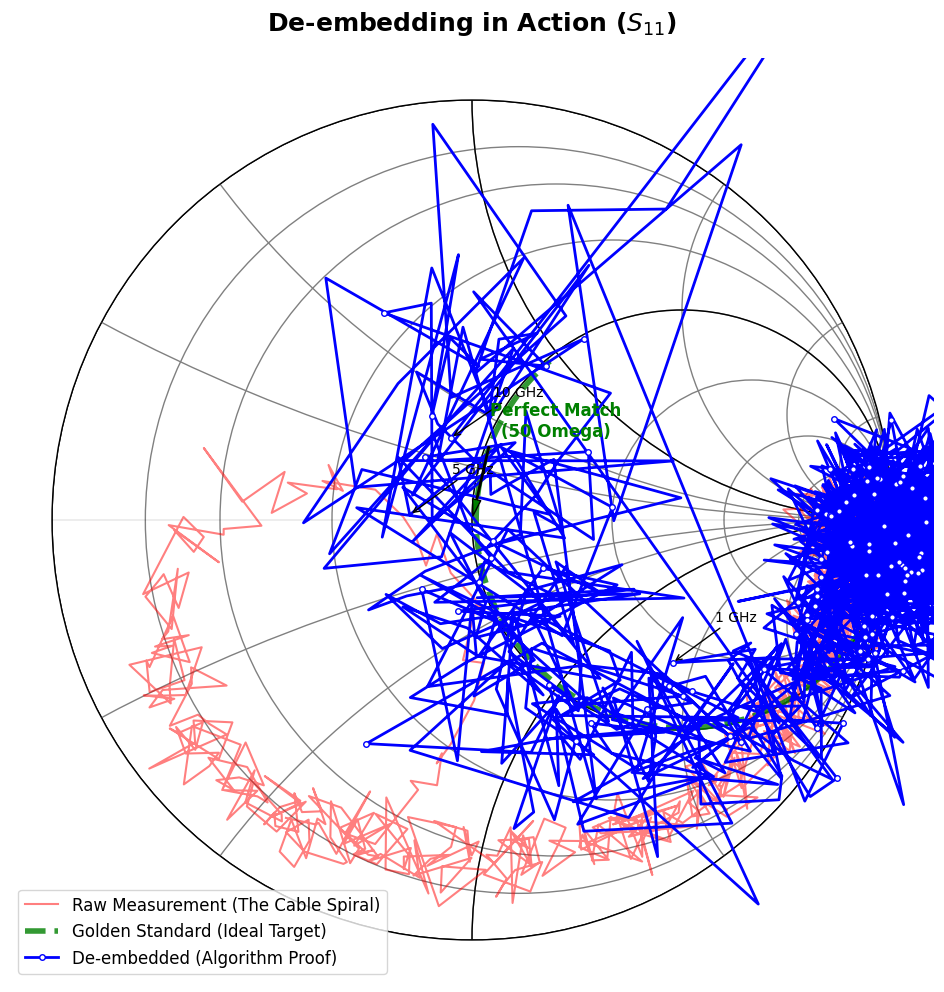

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skrf as rf

# Add the 'src' directory to the Python path so we can import our custom modules
sys.path.append(os.path.abspath('../src'))
from deembedder import deembed_dut, abcd_to_s

# ---------------------------------------------------------
# Helper Function: Turn our CSVs into skrf Network objects
# ---------------------------------------------------------
def load_csv_to_rf_network(csv_file_path, network_name):
    """
    Reads our generated CSV files and constructs a complex S-parameter matrix.
    We need this because the Smith Chart requires both Real and Imaginary parts.
    """
    df = pd.read_csv(csv_file_path)
    freqs = df['frequency_Hz'].values
    
    # Create an empty container for the complex S-parameters (N_points, 2 ports, 2 ports)
    s_matrix = np.zeros((len(freqs), 2, 2), dtype=complex)
    
    # Combine Real and Imaginary parts into complex numbers (Re + j*Im)
    s_matrix[:, 0, 0] = df['S11_real'] + 1j * df['S11_imag']
    s_matrix[:, 0, 1] = df['S12_real'] + 1j * df['S12_imag']
    s_matrix[:, 1, 0] = df['S21_real'] + 1j * df['S21_imag']
    s_matrix[:, 1, 1] = df['S22_real'] + 1j * df['S22_imag']
    
    # Package it into a neat skrf Network object
    net = rf.Network(f=freqs, s=s_matrix, z0=50, name=network_name)
    net.frequency.unit = 'hz' 
    
    return net

# ---------------------------------------------------------
# 1. Load the Base Datasets
# ---------------------------------------------------------
net_raw = load_csv_to_rf_network("../measurement_data/dut_plus_fixture.csv", "Raw (DUT + Fixture)")
net_golden = load_csv_to_rf_network("../measurement_data/golden_dut.csv", "Golden (Ideal DUT)")

# ---------------------------------------------------------
# 2. Execute the De-embedding Algorithm Live!
# ---------------------------------------------------------
print("Running De-embedding algorithm...")

# Fetch the intrinsic ABCD matrix using our custom module
abcd_deembedded = deembed_dut(
    fixture_csv="../measurement_data/fixture.csv", 
    total_csv="../measurement_data/dut_plus_fixture.csv"
)

# Convert back to S-parameters and create the Network object
s_deembedded = abcd_to_s(abcd_deembedded)
net_deembedded = rf.Network(f=net_raw.f, s=s_deembedded, z0=50, name="De-embedded (Our Algorithm)")
net_deembedded.frequency.unit = 'hz'

print("De-embedding complete! Ready to plot.")

# ---------------------------------------------------------
# 3. Draw the Smith Chart
# ---------------------------------------------------------
plt.figure(figsize=(12, 12))

# Plot the Raw Measurement (The problem)
net_raw.plot_s_smith(m=0, n=0, color='red', linewidth=1.5, alpha=0.5,
                     label='Raw Measurement (The Cable Spiral)')

# Plot the Golden Truth (The goal)
net_golden.plot_s_smith(m=0, n=0, color='green', linestyle='--', linewidth=4, alpha=0.8,
                        label='Golden Standard (Ideal Target)')

# Plot the De-embedded Result (The solution)
net_deembedded.plot_s_smith(
    m=0, n=0, color='blue', linewidth=2,
    label='De-embedded (Algorithm Proof)',
    marker='o', markevery=10,  # mark every 10 points
    markersize=4, markerfacecolor='white', markeredgewidth=1
)


# --- Add Annotations ---
ax = plt.gca()

for target_freq in [1e9, 5e9, 10e9]:
    idx = np.argmin(np.abs(net_deembedded.f - target_freq))
    point = net_deembedded.s[idx, 0, 0]
    ax.annotate(f"{target_freq/1e9:.0f} GHz",
                xy=(point.real, point.imag),
                xytext=(point.real + 0.1, point.imag + 0.1),
                arrowprops=dict(arrowstyle="->", color="black"),
                fontsize=10)

ax.annotate('Perfect Match\n(50 Omega)', xy=(0, 0), xytext=(0.2, 0.2),
            arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=6),
            fontsize=12, fontweight='bold', ha='center', color='green')

# Make it look pretty
plt.title("De-embedding in Action ($S_{11}$)", fontsize=18, pad=20, fontweight='bold')
plt.legend(loc='lower left', fontsize=12)
plt.grid(False) 

plt.show()

## The Reality Check: Noise Amplification in De-embedding

In the previous steps, we proved that our de-embedding algorithm is mathematically perfect when given ideal, noiseless data. However, real Vector Network Analyzers (VNAs) always have an inherent noise floor. By injecting synthetic Gaussian noise into our measurements, we observe a fascinating and critical phenomenon.

As we increase the `noise_level` from `0.0001` (high-end VNA) to `0.05` (extremely noisy/poor setup), the de-embedded result (Blue line) starts to degrade, specifically at higher frequencies (towards the 10 GHz mark).

### Why does the algorithm fail at high frequencies?

The breakdown is caused by a combination of physical hardware limitations and mathematical error propagation, known as **Noise Amplification**.

1. **The Physical Reality (Low Signal at High Frequencies):** Our fixture (PAD) contains a parasitic shunt capacitor ($C = 1\text{ pF}$). At low frequencies (e.g., 1 MHz), this capacitor is practically invisible, and the signal passes easily through the fixture. However, at 10 GHz, this capacitor acts almost like a short circuit to ground. The fixture heavily attenuates the signal, meaning very little energy ($S_{21}$) actually reaches the DUT.

2. **The Mathematical Consequence (Division by near-zero):**
   To mathematically remove the fixture, our algorithm converts S-parameters to ABCD matrices. The formula for this conversion requires dividing by the transmission coefficient, $S_{21}$:
   $$A = \frac{(1 + S_{11})(1 - S_{22}) + S_{12}S_{21}}{2 \cdot S_{21}}$$
   
   At 10 GHz, $S_{21}$ is extremely small. When we divide the constant VNA noise (e.g., $0.05$) by an incredibly small signal, the mathematical operation magnifies the noise thousands of times. The Signal-to-Noise Ratio (SNR) drops to near zero.

### Conclusion

De-embedding is a powerful mathematical tool, but **it cannot recover a signal that has been completely buried in the noise floor by a poorly designed fixture.** This experiment proves a fundamental rule of RF engineering: *You cannot fix a bad physical measurement with pure mathematics.* To get accurate high-frequency data, we must design physical fixtures that minimize parasitic capacitance and allow sufficient signal to pass through.